**IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import kagglehub
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import (learning_curve, train_test_split, GridSearchCV)
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

**IMPORT, UPLOAD AND FIRST VIEW OF THE DATASET**

In [ ]:
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
df = pd.read_csv(f"{path}/diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


**MISSING DATA VERIFICATION**

In [ ]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


**NOISY DATA VERIFICATION AND CLEANING**

In [ ]:
noinfo_count = (df['smoking_history'] == "No Info").sum()
other_count = (df['gender'] == "Other").sum()
ever_count = (df['smoking_history'] == "ever").sum()

print(f"# of rows with 'No Info': {noinfo_count}")
print(f"# of rows with 'Other': {other_count}")
print(f"# of rows with 'ever': {ever_count}")

# of rows with 'No Info': 35816
# of rows with 'Other': 18
# of rows with 'ever': 4004


value `No Info` in `smoking history` has too many observation and it's manageable so we keep it, we've decided to remove only `gender` = `Other` and `smoking history` = `ever` for the low number of observations and for the possible incomprehensibility for the models

In [ ]:
df = df[df['gender'] != 'Other']
df = df[df['smoking_history'] != 'ever']

**VARIABLES ADJUST**

In [ ]:
df['smoking_history'] = df['smoking_history'].replace(
    ['former', 'not current'],
    'past smoker'
)

analyzing the dataset we've found that the values `former` and `not current` of the feature `smoking history` were likely the same, so we've decided to combine them in a single value and call it `past smoker`

**DATASET SPLIT INTO TRAINING, VALIDATON AND TEST SET**

In [ ]:
#target variable is 'diabetes'
X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,   #split into training+validation(80%) and test(20%)
    random_state=42,
    stratify=y #stratify=y ensures that the proportion of the target class is preserved in all splits.
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,     #split training+validation, 0.25 of 0.80 = 0.20
    random_state=42,
    stratify=y_train_val
)

print(f"X Total:            {X.shape}")
print(f"X Training:          {X_train.shape}   (60% of data)")
print(f"X Validation:        {X_validation.shape} (20% of data)")
print(f"X Test:              {X_test.shape}   (20% of data)")

X Total:            (95979, 8)
X Training:          (57587, 8)   (60% of data)
X Validation:        (19196, 8) (20% of data)
X Test:              (19196, 8)   (20% of data)


**UTILITY FUNCTION FOR LEARNING CURVES**

In [ ]:
#function to plot learning curves
def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring='f1'):
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel(f"Score ({scoring})")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring=scoring)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

#plotting mean and standard deviation of training and cross-validation scores
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    plt.show()

**DATASET PREPROCESSING**

In [ ]:
#defining features by type for the ColumnTransformer
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical_features = ['gender', 'smoking_history']
binary_passthrough_features = ['hypertension', 'heart_disease']

#ColumnTransformer applies specific transformations to specific column types in parallel
preprocessor = ColumnTransformer(
    transformers=[
        ('scaling', StandardScaler(), numerical_features),
        ('encoding', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('passthrough', 'passthrough', binary_passthrough_features) #binary features (0/1) are passed through unchanged
    ],
    remainder='drop'
)

preprocessor.fit(X_train) #fit the preprocessor only on the training data to prevent data leakage
#retrieves the names of the newly encoded columns for DataFrame creation
encoded_col_names = np.concatenate([
    preprocessor.named_transformers_['scaling'].get_feature_names_out(numerical_features),
    preprocessor.named_transformers_['encoding'].get_feature_names_out(categorical_features),
    binary_passthrough_features
])
#transforms data and recreates DataFrames for downstream modeling
X_train_processed = pd.DataFrame(preprocessor.transform(X_train), columns=encoded_col_names)
X_validation_processed = pd.DataFrame(preprocessor.transform(X_validation), columns=encoded_col_names)
#concatenated data for use in learning curves
X_train_val_processed = pd.concat([X_train_processed, X_validation_processed], ignore_index=True)
y_train_val_concat = pd.concat([y_train, y_validation], ignore_index=True)

two different operations for two different types of features:

1.   **SCALE** for numerical features, important because many machine learning algorithms are sensitive to the scale of the data. If you don't scale, the model will be biased.
2.   **ENCODE** for categorical features, essential because machine learning algorithms are mathematical and cannot process text. The solution is to translate these non-numerical categories into a dicotomical numerical format through encode process; we've chosen the commonly used **One-Hot Encoding**

to do these processings all simultaneously, `preprocessor` (`ColumnTransformer`) is used. its purpose is to apply different transformations (Scaling and One-Hot Encoding) to different types of columns in one step.


**NAIVE BAYES**

Computational Cost: 0.14 seconds

Accuracy on Training Set: 0.9033
Accuracy on Validation Set: 0.9068
              precision    recall  f1-score   support

 No Diabetes       0.97      0.93      0.95     17590
    Diabetes       0.46      0.67      0.55      1606

    accuracy                           0.91     19196
   macro avg       0.71      0.80      0.75     19196
weighted avg       0.93      0.91      0.91     19196



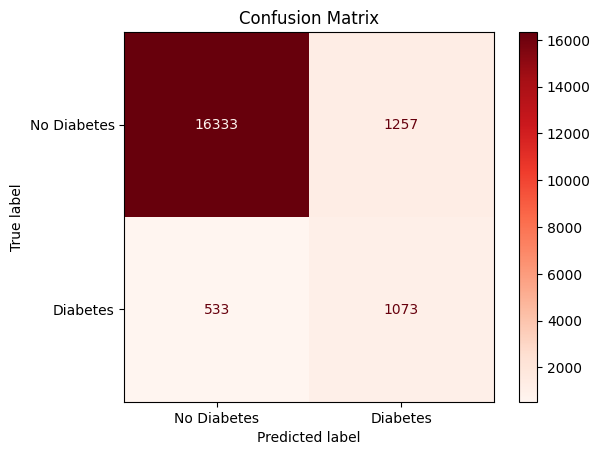

AUC Score: 0.9224


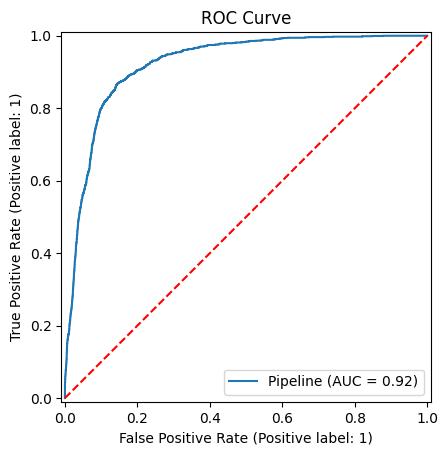

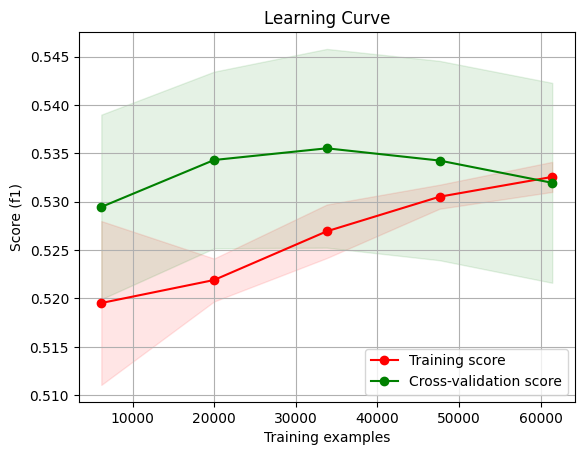

In [ ]:
#pipeline combines preprocessing (preprocessor) and the classifier (GaussianNB)
gnb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])
#measuring the computational cost (training time)
start_time_gnb = time.time()
gnb_pipeline.fit(X_train, y_train)
end_time_gnb = time.time()
training_time_gnb = end_time_gnb - start_time_gnb

print(f"Computational Cost: {training_time_gnb:.2f} seconds")

gnb_score_train = gnb_pipeline.score(X_train, y_train)
print(f"\nAccuracy on Training Set: {gnb_score_train:.4f}")
gnb_score_val = gnb_pipeline.score(X_validation, y_validation)
print(f"Accuracy on Validation Set: {gnb_score_val:.4f}")

#evaluating the final GNB model
y_pred_gnb = gnb_pipeline.predict(X_validation)

print(classification_report(y_validation, y_pred_gnb, target_names=['No Diabetes', 'Diabetes']))

ConfusionMatrixDisplay.from_predictions(y_validation, y_pred_gnb, display_labels=['No Diabetes', 'Diabetes'], cmap='Reds')
plt.title("Confusion Matrix")
plt.show()

y_proba_gnb = gnb_pipeline.predict_proba(X_validation)[:, 1]
auc_score_gnb = roc_auc_score(y_validation, y_proba_gnb)
print(f"AUC Score: {auc_score_gnb:.4f}")

RocCurveDisplay.from_estimator(gnb_pipeline, X_validation, y_validation)
plt.title("ROC Curve")
plt.plot([0, 1], [0, 1], 'r--')
plt.show()

X_train_val_concat = pd.concat([X_train, X_validation], ignore_index=True)
y_train_val_concat = pd.concat([y_train, y_validation], ignore_index=True)

plot_learning_curve(gnb_pipeline, "Learning Curve",
                    X_train_val_concat, y_train_val_concat, cv=5, scoring='f1')

**HYPERPARAMETERS SEARCH FOR DECISION TREE**

In [ ]:
#pipeline combines preprocessing (preprocessor) and the classifier (DecisionTreeClassifier)
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])
#define the grid of hyperparameters to search through
param_grid_dt_pipeline = {
    'classifier__max_depth': [5, 8, 10, 12, 15], #controls tree depth (regularization)
    'classifier__min_samples_split': [10, 20] #minimum samples required to split a node (pruning)
}

start_time_dt_pruned = time.time()
grid_search_dt_pruned = GridSearchCV( #use GridSearchCV to perform cross-validated search for the best hyperparameters
    estimator=dt_pipeline,
    param_grid=param_grid_dt_pipeline,
    scoring='f1',  #F1-score is used as the primary metric, suitable for imbalanced classification
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_dt_pruned.fit(X_train, y_train)
end_time_dt_pruned = time.time()
training_time_dt_pruned = end_time_dt_pruned - start_time_dt_pruned

best_dt_model_pruned = grid_search_dt_pruned.best_estimator_

print(f"\nBest hyperparameters found: {grid_search_dt_pruned.best_params_}")
print(f"Computational Cost: {training_time_dt_pruned:.2f} seconds")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best hyperparameters found: {'classifier__max_depth': 15, 'classifier__min_samples_split': 10}
Computational Cost: 16.32 seconds


`param_grid_dt_pipeline`is used to set limits and prune the decision tree, to speed up the optimal hyperparameters search. this stops the tree early, preventing it from memorizing the training data, from overfitting.

**DECISION TREE IMPLEMENTATIONS AND RESULTS**


Accuracy on Training Set: 0.9257
Accuracy on Validation Set: 0.9102
              precision    recall  f1-score   support

 No Diabetes       0.99      0.91      0.95     17590
    Diabetes       0.48      0.86      0.62      1606

    accuracy                           0.91     19196
   macro avg       0.73      0.89      0.78     19196
weighted avg       0.94      0.91      0.92     19196



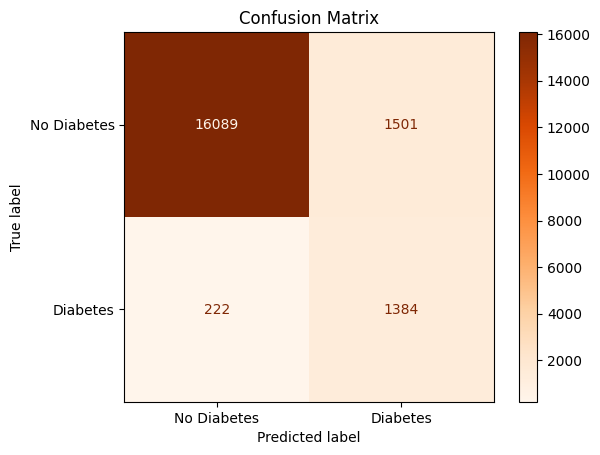

AUC Score: 0.9357


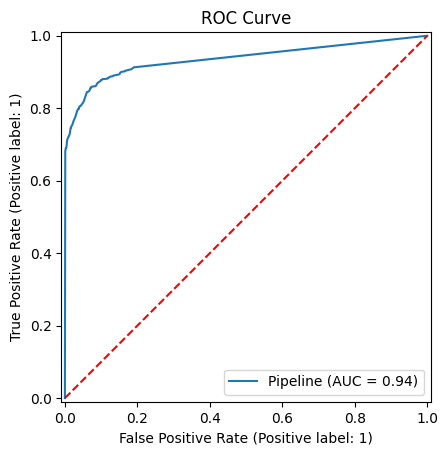

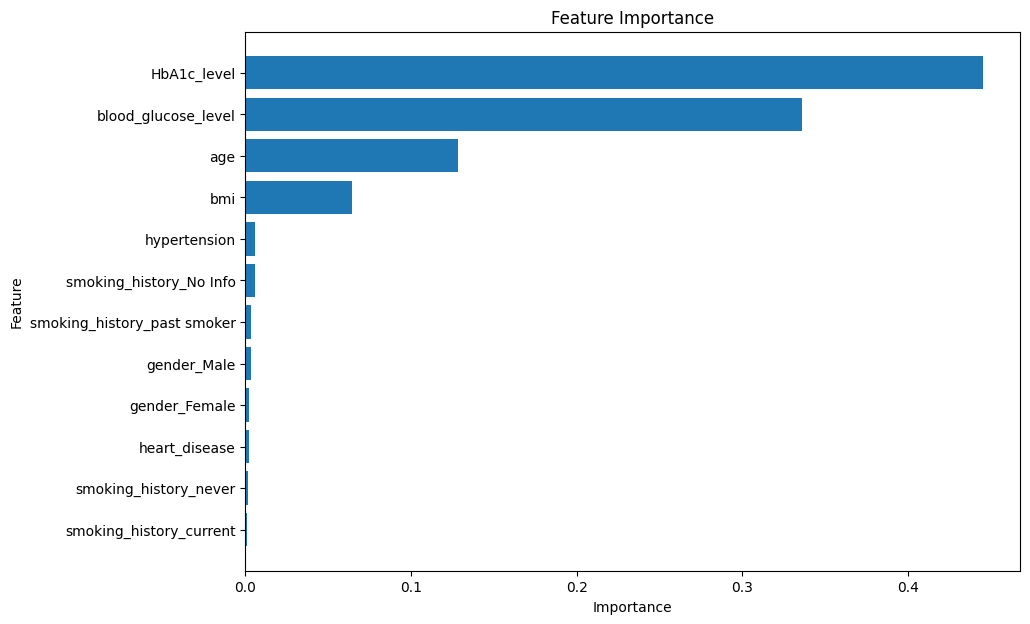

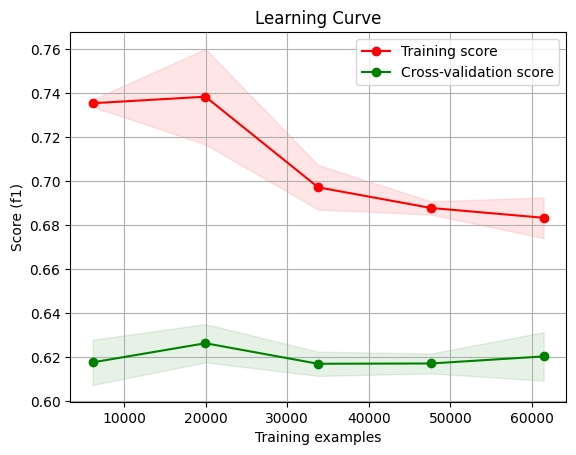

In [ ]:
#evaluating the final DT model
dt_score_train_pruned = best_dt_model_pruned.score(X_train, y_train)
print(f"\nAccuracy on Training Set: {dt_score_train_pruned:.4f}")
dt_score_val_pruned = best_dt_model_pruned.score(X_validation, y_validation)
print(f"Accuracy on Validation Set: {dt_score_val_pruned:.4f}")

y_pred_dt_pruned = best_dt_model_pruned.predict(X_validation)

print(classification_report(y_validation, y_pred_dt_pruned, target_names=['No Diabetes', 'Diabetes']))

ConfusionMatrixDisplay.from_predictions(y_validation, y_pred_dt_pruned, display_labels=['No Diabetes', 'Diabetes'], cmap='Oranges')
plt.title("Confusion Matrix")
plt.show()

y_proba_dt_pruned = best_dt_model_pruned.predict_proba(X_validation)[:, 1]
auc_score_dt_pruned = roc_auc_score(y_validation, y_proba_dt_pruned)
print(f"AUC Score: {auc_score_dt_pruned:.4f}")

RocCurveDisplay.from_estimator(best_dt_model_pruned, X_validation, y_validation)
plt.title("ROC Curve")
plt.plot([0, 1], [0, 1], 'r--')
plt.show()

feature_names_dt = X_train_processed.columns
dt_classifier = best_dt_model_pruned.named_steps['classifier']
importances_dt = dt_classifier.feature_importances_

feature_importance_dt = pd.DataFrame({'feature': feature_names_dt, 'importance': importances_dt})
feature_importance_dt = feature_importance_dt.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 7))
plt.title("Feature Importance")
plt.barh(feature_importance_dt['feature'], feature_importance_dt['importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

plot_learning_curve(best_dt_model_pruned, "Learning Curve",
                    pd.concat([X_train, X_validation]), pd.concat([y_train, y_validation]), cv=5, scoring='f1')

**HYPERPARAMETERS SEARCH FOR RANDOM FOREST**

In [ ]:
#pipeline combines preprocessing (preprocessor) and the classifier (RandomForestClassifier)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
#define the hyperparameter grid (n_estimators controls the number of trees)
param_grid_rf_pipeline = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, 30] #controls the depth of individual trees
}

start_time_rf_pruned = time.time()
grid_search_rf_pruned = GridSearchCV( #use GridSearchCV to find the best Random Forest configuration
    estimator=rf_pipeline,
    param_grid=param_grid_rf_pipeline,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search_rf_pruned.fit(X_train, y_train)
end_time_rf_pruned = time.time()
training_time_rf_pruned = end_time_rf_pruned - start_time_rf_pruned

best_rf_model_pruned = grid_search_rf_pruned.best_estimator_

print(f"\nBest hyperparameters found: {grid_search_rf_pruned.best_params_}")
print(f"Computational Cost: {training_time_rf_pruned:.2f} seconds")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best hyperparameters found: {'classifier__max_depth': 30, 'classifier__n_estimators': 200}
Computational Cost: 78.94 seconds


just like decision tree, `param_grid_rf_pipeline` is used for the same purpose

**RANDOM FOREST IMPLEMENTATION**


Accuracy on Training Set: 0.9990
Accuracy on Validation Set: 0.9709
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     17590
    Diabetes       0.93      0.70      0.80      1606

    accuracy                           0.97     19196
   macro avg       0.95      0.85      0.89     19196
weighted avg       0.97      0.97      0.97     19196



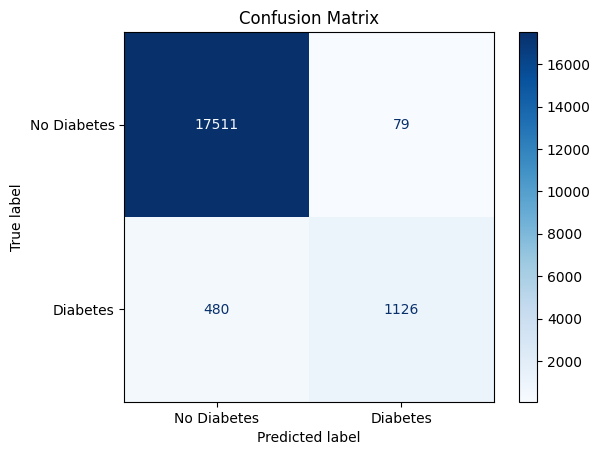

AUC Score: 0.9706


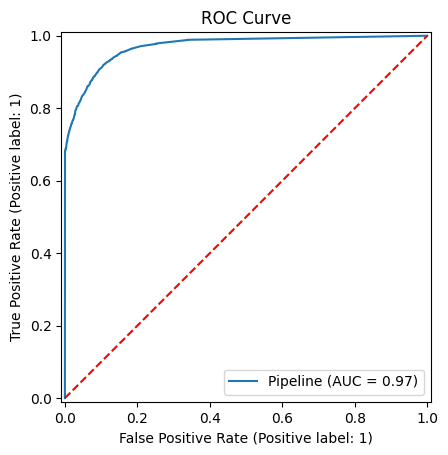

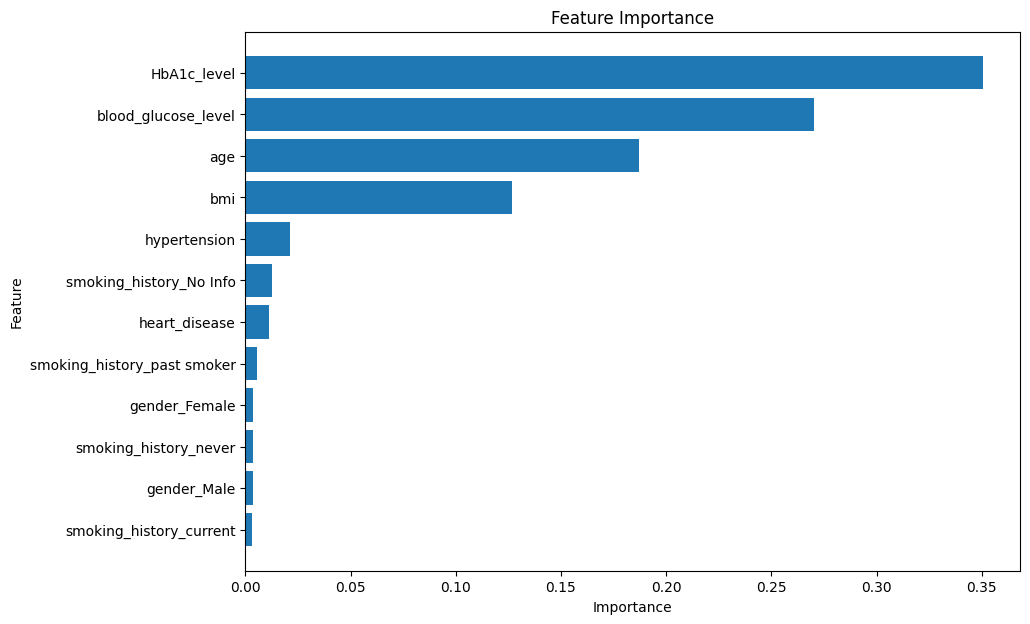

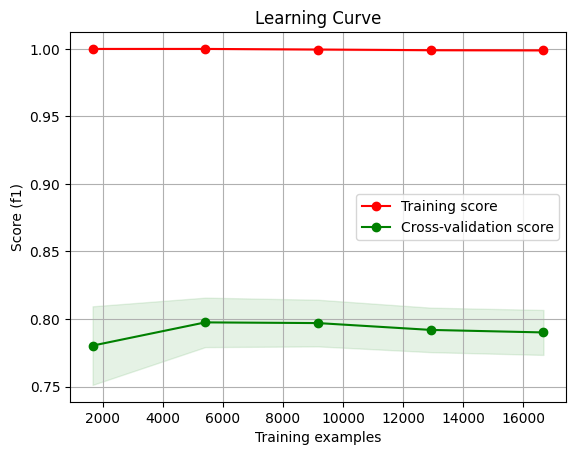

In [ ]:
#evaluating the final RF model
rf_score_train_pruned = best_rf_model_pruned.score(X_train, y_train)
print(f"\nAccuracy on Training Set: {rf_score_train_pruned:.4f}")
rf_score_val_pruned = best_rf_model_pruned.score(X_validation, y_validation)
print(f"Accuracy on Validation Set: {rf_score_val_pruned:.4f}")

y_pred_rf_pruned = best_rf_model_pruned.predict(X_validation)

print(classification_report(y_validation, y_pred_rf_pruned, target_names=['No Diabetes', 'Diabetes']))

ConfusionMatrixDisplay.from_predictions(y_validation, y_pred_rf_pruned, display_labels=['No Diabetes', 'Diabetes'], cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

y_proba_rf_pruned = best_rf_model_pruned.predict_proba(X_validation)[:, 1]
auc_score_rf_pruned = roc_auc_score(y_validation, y_proba_rf_pruned)
print(f"AUC Score: {auc_score_rf_pruned:.4f}")

RocCurveDisplay.from_estimator(best_rf_model_pruned, X_validation, y_validation)
plt.title("ROC Curve")
plt.plot([0, 1], [0, 1], 'r--')
plt.show()

rf_classifier = best_rf_model_pruned.named_steps['classifier']
importances_rf = rf_classifier.feature_importances_

feature_importance_rf = pd.DataFrame({'feature': X_train_processed.columns, 'importance': importances_rf})
feature_importance_rf = feature_importance_rf.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 7))
plt.title("Feature Importance")
plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

X_train_val_concat_raw = pd.concat([X_train, X_validation], ignore_index=True)
y_train_val_concat_raw = pd.concat([y_train, y_validation], ignore_index=True)

X_train_val_subset, _, y_train_val_subset, _ = train_test_split(
    X_train_val_concat_raw,
    y_train_val_concat_raw,
    train_size=25000,
    random_state=42,
    stratify=y_train_val_concat_raw
)
plot_learning_curve(best_rf_model_pruned, "Learning Curve",
                    X_train_val_subset, y_train_val_subset, cv=3, scoring='f1')

**HYPERPARAMETERS SEARCH FOR LOGISTIC REGRESSION**

In [ ]:
#pipeline combines preprocessing (preprocessor) and the classifier (LogisticRegression)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])
#hyperparameter grid for regularization strength (C)
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100] #C is the inverse of regularization strength
}

start_time_lr = time.time()

grid_search_lr = GridSearchCV( #use GridSearchCV to find the optimal C parameter
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(X_train, y_train)

end_time_lr = time.time()
training_time_lr = end_time_lr - start_time_lr

best_lr_model = grid_search_lr.best_estimator_

print(f"Best hyperparameters found: {grid_search_lr.best_params_}")
print(f"Computational Cost: {training_time_lr:.2f} seconds")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best hyperparameters found: {'classifier__C': 0.1}
Computational Cost: 3.38 seconds


hyperparameter optimization for the Logistic Regression model using `GridSearchCV` to test a range of values for the C parameter. we're using `class_weight='balanced'` on the base model to further address the class imbalance (we know that number of non-diabethic observations is way bigger than the diabethic one)

**LOGISTIC REGRESSION IMPLEMENTATION AND RESULTS REPRESENTATION**


Accuracy on Training Set: 0.8873
Accuracy on Validation Set: 0.8903
              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     17590
    Diabetes       0.43      0.90      0.58      1606

    accuracy                           0.89     19196
   macro avg       0.71      0.89      0.76     19196
weighted avg       0.94      0.89      0.91     19196



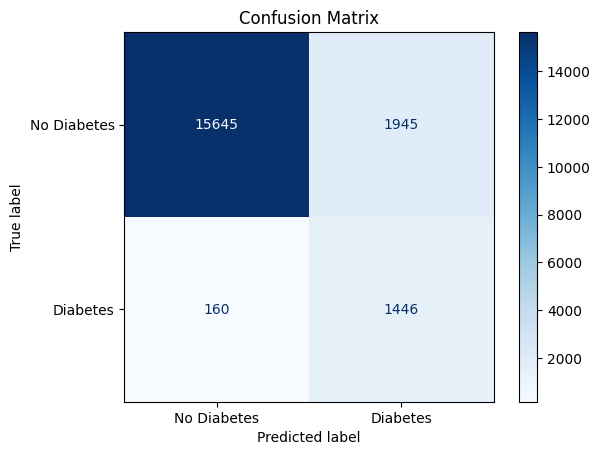

AUC Score: 0.9665


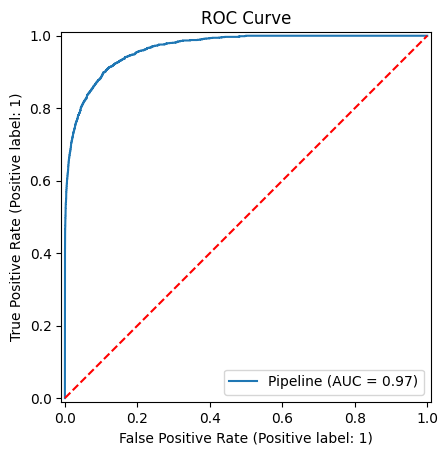

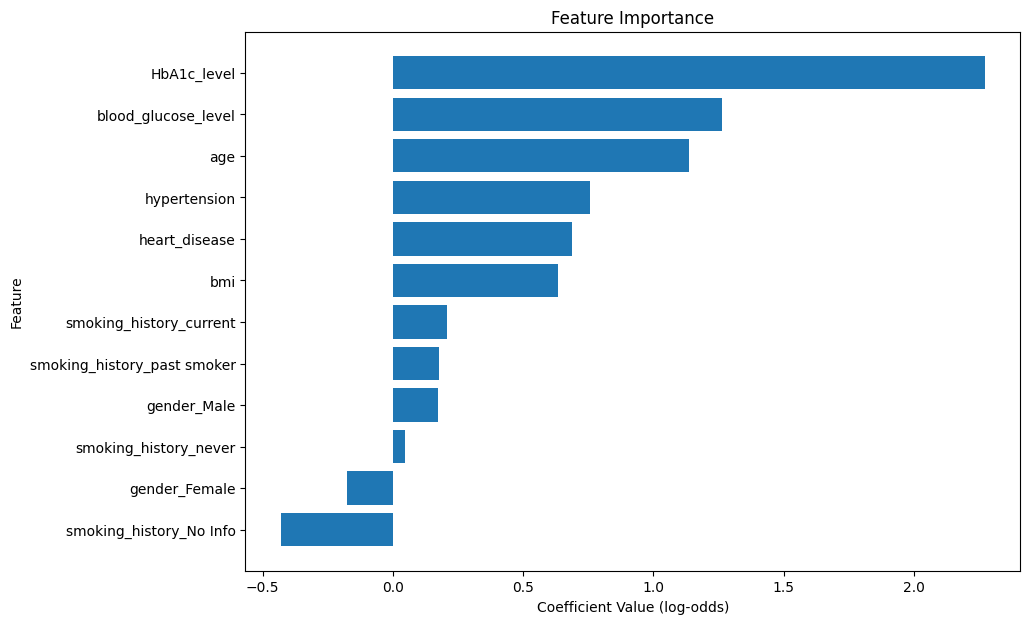

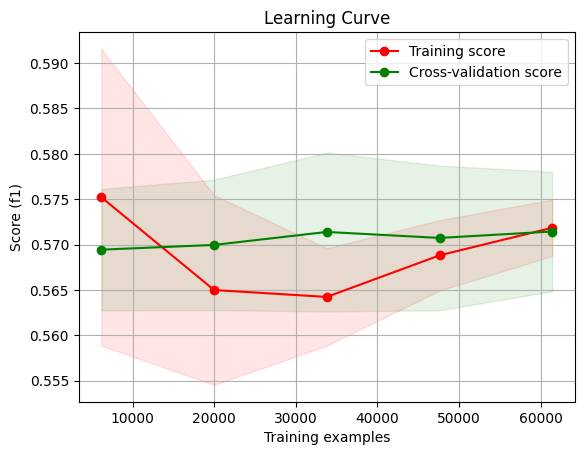

In [ ]:
#evaluating the final LR model
lr_score_train = best_lr_model.score(X_train, y_train)
print(f"\nAccuracy on Training Set: {lr_score_train:.4f}")
lr_score_val = best_lr_model.score(X_validation, y_validation)
print(f"Accuracy on Validation Set: {lr_score_val:.4f}")

y_pred_lr = best_lr_model.predict(X_validation)

print(classification_report(y_validation, y_pred_lr, target_names=['No Diabetes', 'Diabetes']))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    y_pred_lr,
    display_labels=['No Diabetes', 'Diabetes'],
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.show()

y_proba_lr = best_lr_model.predict_proba(X_validation)[:, 1]
auc_score = roc_auc_score(y_validation, y_proba_lr)
print(f"AUC Score: {auc_score:.4f}")

RocCurveDisplay.from_estimator(best_lr_model, X_validation, y_validation)
plt.title("ROC Curve")
plt.plot([0, 1], [0, 1], 'r--')
plt.show()

lr_classifier = best_lr_model.named_steps['classifier']
importances_lr = lr_classifier.coef_[0]

feature_names_lr = X_train_processed.columns

feature_importance_lr = pd.DataFrame({'feature': feature_names_lr, 'importance (coefficient)': importances_lr})
feature_importance_lr = feature_importance_lr.sort_values(by='importance (coefficient)', ascending=False)

plt.figure(figsize=(10, 7))
plt.title("Feature Importance")
plt.barh(feature_importance_lr['feature'], feature_importance_lr['importance (coefficient)'])
plt.xlabel("Coefficient Value (log-odds)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

plot_learning_curve(best_lr_model, "Learning Curve",
                    pd.concat([X_train, X_validation]), pd.concat([y_train, y_validation]), cv=5, scoring='f1')

**HYPERPARAMETERS SEARCH FOR SVM**

In [ ]:
#pipeline combines preprocessing (preprocessor) and the classifier (SVC)
svm_pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, class_weight='balanced'))
])
#hyperparameter grid for C (regularization) and forcing 'linear' kernel for interpretability/speed
param_grid_svm_pipeline = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear']
}
#creating a small subset of the training data for faster GridSearch, as SVM is computationally intensive (O(n^2) or O(n^3))
X_train_subset, _, y_train_subset, _ = train_test_split(
    X_train,
    y_train,
    train_size=15000,
    random_state=42,
    stratify=y_train
)
print(f"Subset shape (Raw Data): {X_train_subset.shape}")

#gridSearch performed on the SUBSET
start_time_svm = time.time()
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline_base,
    param_grid=param_grid_svm_pipeline,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid_search_svm.fit(X_train_subset, y_train_subset)

end_time_svm = time.time()
training_time_svm = end_time_svm - start_time_svm

best_svm_model = grid_search_svm.best_estimator_

print(f"Best hyperparameters found: {grid_search_svm.best_params_}")
print(f"Total training time (Subset GridSearch): {training_time_svm:.2f} seconds")

#re-trains the best model found on the full training set
print("\nRe-training the best model on the FULL training set")
start_fit_full = time.time()
best_svm_model.fit(X_train, y_train)
end_fit_full = time.time()
print(f"Full re-training finished in {(end_fit_full - start_fit_full):.2f} seconds.")

Subset shape (Raw Data): (15000, 8)
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best hyperparameters found: {'classifier__C': 0.1, 'classifier__kernel': 'linear'}
Total training time (Subset GridSearch): 26.92 seconds

Re-training the best model on the FULL training set
Full re-training finished in 49.65 seconds.


just like the previous model, but with few details to speed up the otherwise SVM long implementation process:  

1.   a subset of 15000 samples is used to find the best hyperparameters and then try those hyperparameters in the full training set
2.   `linear` kernel function is forced, not conceeding the option `rbf`







**SVM IMPLEMENTATION AND RESULTS REPRESENTATION**


Accuracy on Training Set: 0.8858
Accuracy on Validation Set: 0.8887
              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     17590
    Diabetes       0.42      0.90      0.58      1606

    accuracy                           0.89     19196
   macro avg       0.71      0.90      0.76     19196
weighted avg       0.94      0.89      0.91     19196



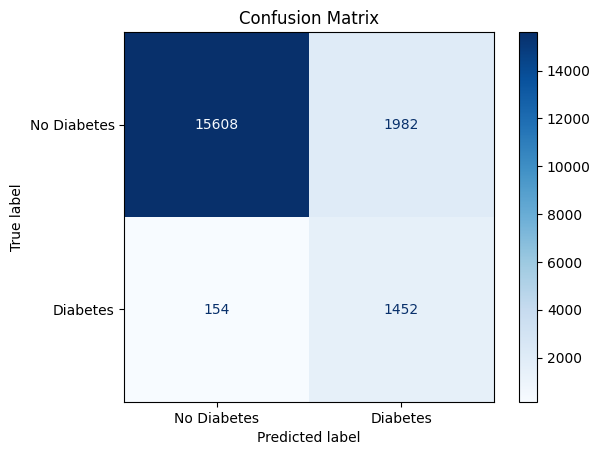

Re-training the best model with probability=True on the FULL training set...
Full re-training finished in 364.10 seconds.
AUC Score: 0.9663


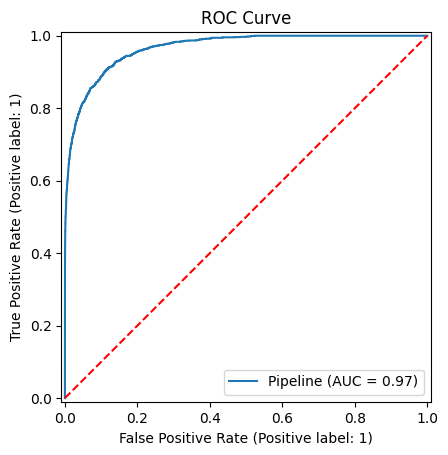

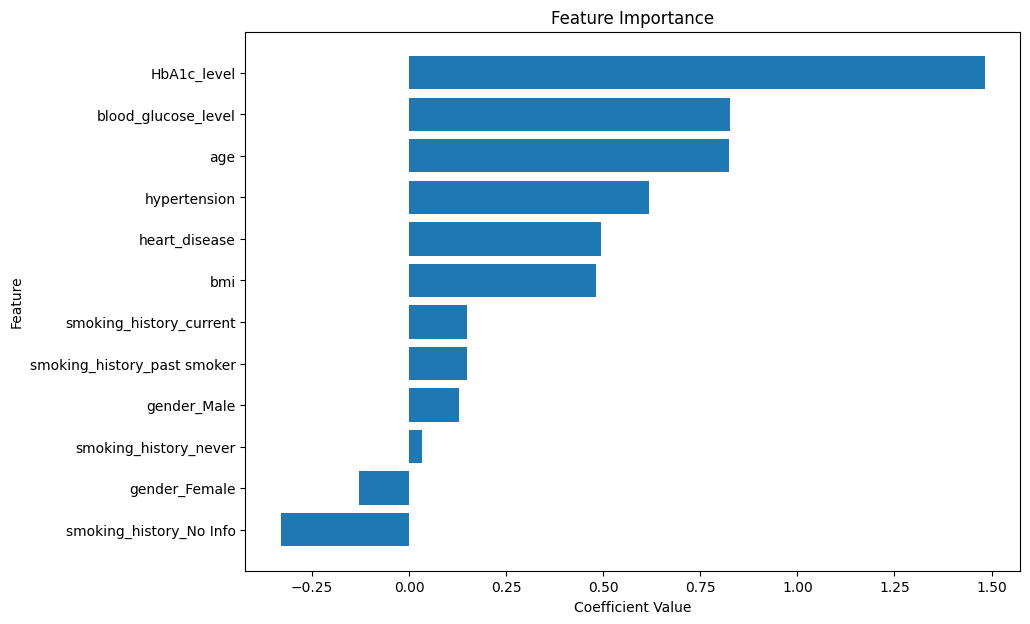

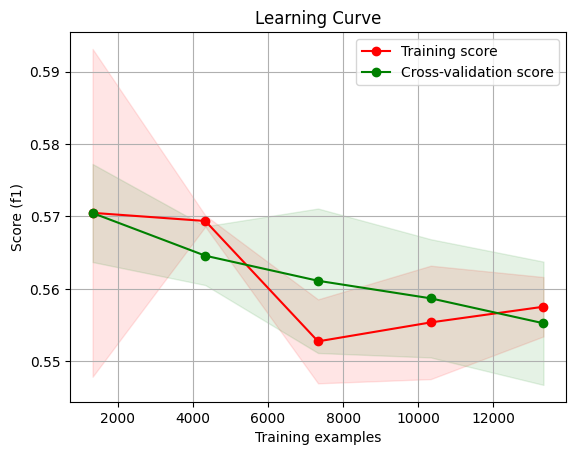

In [ ]:
#evaluating the final SVM model
svm_score_train = best_svm_model.score(X_train, y_train)
print(f"\nAccuracy on Training Set: {svm_score_train:.4f}")
svm_score_val = best_svm_model.score(X_validation, y_validation)
print(f"Accuracy on Validation Set: {svm_score_val:.4f}")

y_pred_svm = best_svm_model.predict(X_validation)

print(classification_report(y_validation, y_pred_svm, target_names=['No Diabetes', 'Diabetes']))

ConfusionMatrixDisplay.from_predictions(y_validation, y_pred_svm, display_labels=['No Diabetes', 'Diabetes'], cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

svm_classifier = best_svm_model.named_steps['classifier']

if hasattr(svm_classifier, "probability") and not svm_classifier.probability:
    start_prob_fit = time.time()
    print("Re-training the best model with probability=True on the FULL training set...")

    new_svm_pipeline = Pipeline(steps=[
        ('preprocessor', best_svm_model.named_steps['preprocessor']),
        ('classifier', SVC(
            C=svm_classifier.C,
            kernel=svm_classifier.kernel,
            class_weight='balanced',
            random_state=42,
            probability=True
        ))
    ])
    new_svm_pipeline.fit(X_train, y_train)
    best_svm_model = new_svm_pipeline

    end_prob_fit = time.time()
    print(f"Full re-training finished in {(end_prob_fit - start_prob_fit):.2f} seconds.")

RocCurveDisplay.from_estimator(best_svm_model, X_validation, y_validation)
auc_score_svm = roc_auc_score(y_validation, best_svm_model.predict_proba(X_validation)[:, 1])
print(f"AUC Score: {auc_score_svm:.4f}")
plt.title("ROC Curve")
plt.plot([0, 1], [0, 1], 'r--')
plt.show()

if svm_classifier.kernel == 'linear':
    feature_names_svm = X_train_processed.columns

    importances_svm = best_svm_model.named_steps['classifier'].coef_[0]

    feature_importance_svm = pd.DataFrame({'feature': feature_names_svm, 'importance (coefficient)': importances_svm})
    feature_importance_svm = feature_importance_svm.sort_values(by='importance (coefficient)', ascending=False)

    plt.figure(figsize=(10, 7))
    plt.title("Feature Importance")
    plt.barh(feature_importance_svm['feature'], feature_importance_svm['importance (coefficient)'])
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.show()

X_train_val_raw = pd.concat([X_train, X_validation])
y_train_val_concat_raw = pd.concat([y_train, y_validation])

X_train_val_subset, _, y_train_val_subset, _ = train_test_split(
    X_train_val_raw,
    y_train_val_concat_raw,
    train_size=20000,
    random_state=42,
    stratify=y_train_val_concat_raw
)

plot_learning_curve(best_svm_model, f"Learning Curve",
                    X_train_val_subset, y_train_val_subset, cv=3, scoring='f1')